# PhishGuard — Exploratory Data Analysis (EDA)
### Phase 3: Dataset Characterization and Feature Separation Analysis

**Objective**:
Analyze the preprocessed URL dataset (`data/processed/features.csv`) to validate class balance, examine statistical distributions of continuous and discrete features, assess the prevalence of key security indicators across classes, and evaluate feature correlations with the target label (`label: 1 = phishing, 0 = legitimate`).

All generated figures are saved to `evaluation/` at 150 DPI for use in the final research report.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Styling settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

EVAL_DIR = Path("../evaluation")
EVAL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/processed/features.csv")
print(f"Loaded dataset: {df.shape[0]} samples, {df.shape[1]} columns")
print(f"Features: {[c for c in df.columns if c not in ['url', 'label']]}")
print(f"Null values: {df.isnull().sum().sum()}")
df.head(5)


Loaded dataset: 10000 samples, 21 columns
Features: ['url_length', 'has_ip_address', 'has_at_symbol', 'num_hyphens_in_domain', 'num_dots', 'num_subdomains', 'has_https', 'has_suspicious_tld', 'has_url_shortener', 'digit_ratio', 'has_double_slash_in_path', 'special_char_count', 'domain_length', 'has_brand_keyword_mismatch', 'path_length', 'num_query_params', 'has_redirect_in_query', 'url_entropy', 'has_port_in_url']
Null values: 0


,url_length,has_ip_address,has_at_symbol,num_hyphens_in_domain,num_dots,num_subdomains,has_https,has_suspicious_tld,has_url_shortener,digit_ratio,...,special_char_count,domain_length,has_brand_keyword_mismatch,path_length,num_query_params,has_redirect_in_query,url_entropy,has_port_in_url,url,label
0,17,0,0,0,1,0,1,0,0,0.000000,...,0,5,0,0,0,0,3.734522,0,https://xfree.com,0
1,22,0,0,0,1,0,1,0,1,0.136364,...,0,3,0,8,0,0,4.027169,0,https://bit.ly/3Y4MU7B,1
2,41,0,0,0,2,1,1,0,0,0.024390,...,0,3,0,25,0,0,4.552197,0,https://l.ead.me/bfKASoDFBbsrhetjw4hwjnmn,1
3,37,0,0,1,2,1,0,0,0,0.189189,...,0,16,0,0,0,0,4.378240,0,http://allegro.pl-oferta6482538.click,1
4,175,0,0,0,2,1,1,0,0,0.108571,...,5,6,0,108,3,0,5.588574,0,https://docs.google.com/presentation/d/e/2PACX...,1


## 1. Class Distribution Analysis
Checking that the dataset is balanced 50/50 to avoid majority class bias and ensure proper training signals.


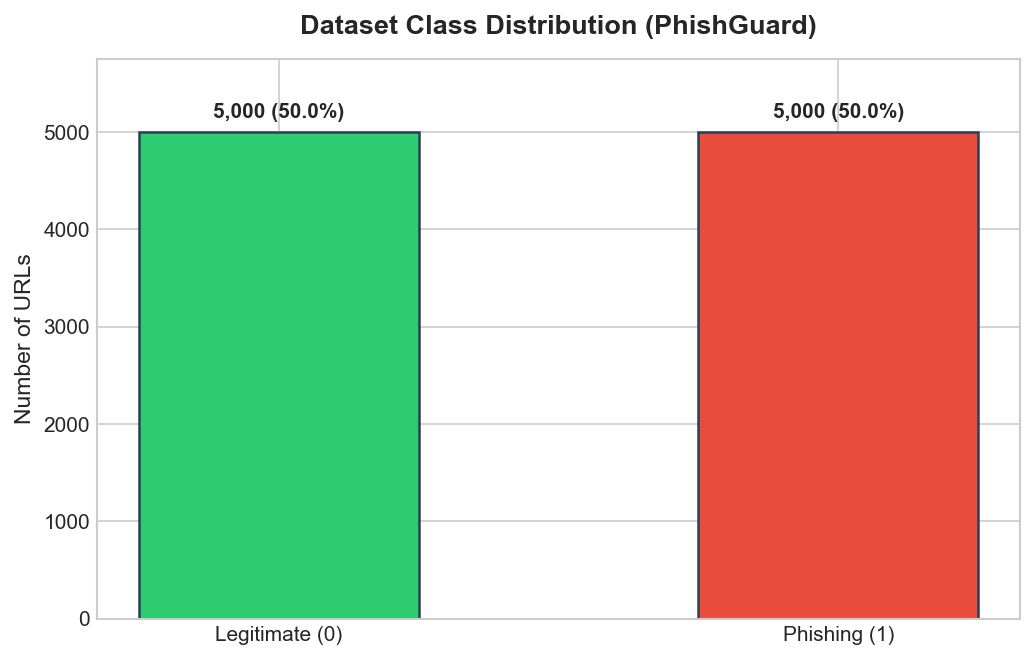

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
label_counts = df["label"].value_counts().sort_index()
classes = ["Legitimate (0)", "Phishing (1)"]
colors = ["#2ecc71", "#e74c3c"]

bars = ax.bar(classes, label_counts.values, color=colors, edgecolor="#2c3e50", width=0.5, linewidth=1.2)
ax.set_title("Dataset Class Distribution (PhishGuard)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Number of URLs", fontsize=11)
ax.set_ylim(0, max(label_counts.values) * 1.15)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:,} ({height/len(df)*100:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha="center", va="bottom", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig(EVAL_DIR / "class_balance.png", dpi=150)
plt.show()


## 2. Continuous Feature Distributions (Violin Plots)
Examining 6 key continuous features across both classes to verify statistical separation:
- `url_length`: Phishing URLs are typically longer to accommodate obfuscating subdomains/tokens.
- `num_subdomains`: Multiple nested subdomains are heavily utilized in impersonation attacks.
- `num_dots`: Excessive dots indicate subdomain nesting and obfuscation.
- `digit_ratio`: DGA and IP-based URLs contain a much higher ratio of numbers.
- `domain_length`: Domain character length variances.
- `url_entropy`: Higher Shannon entropy reflects random token generation and pseudo-random paths.


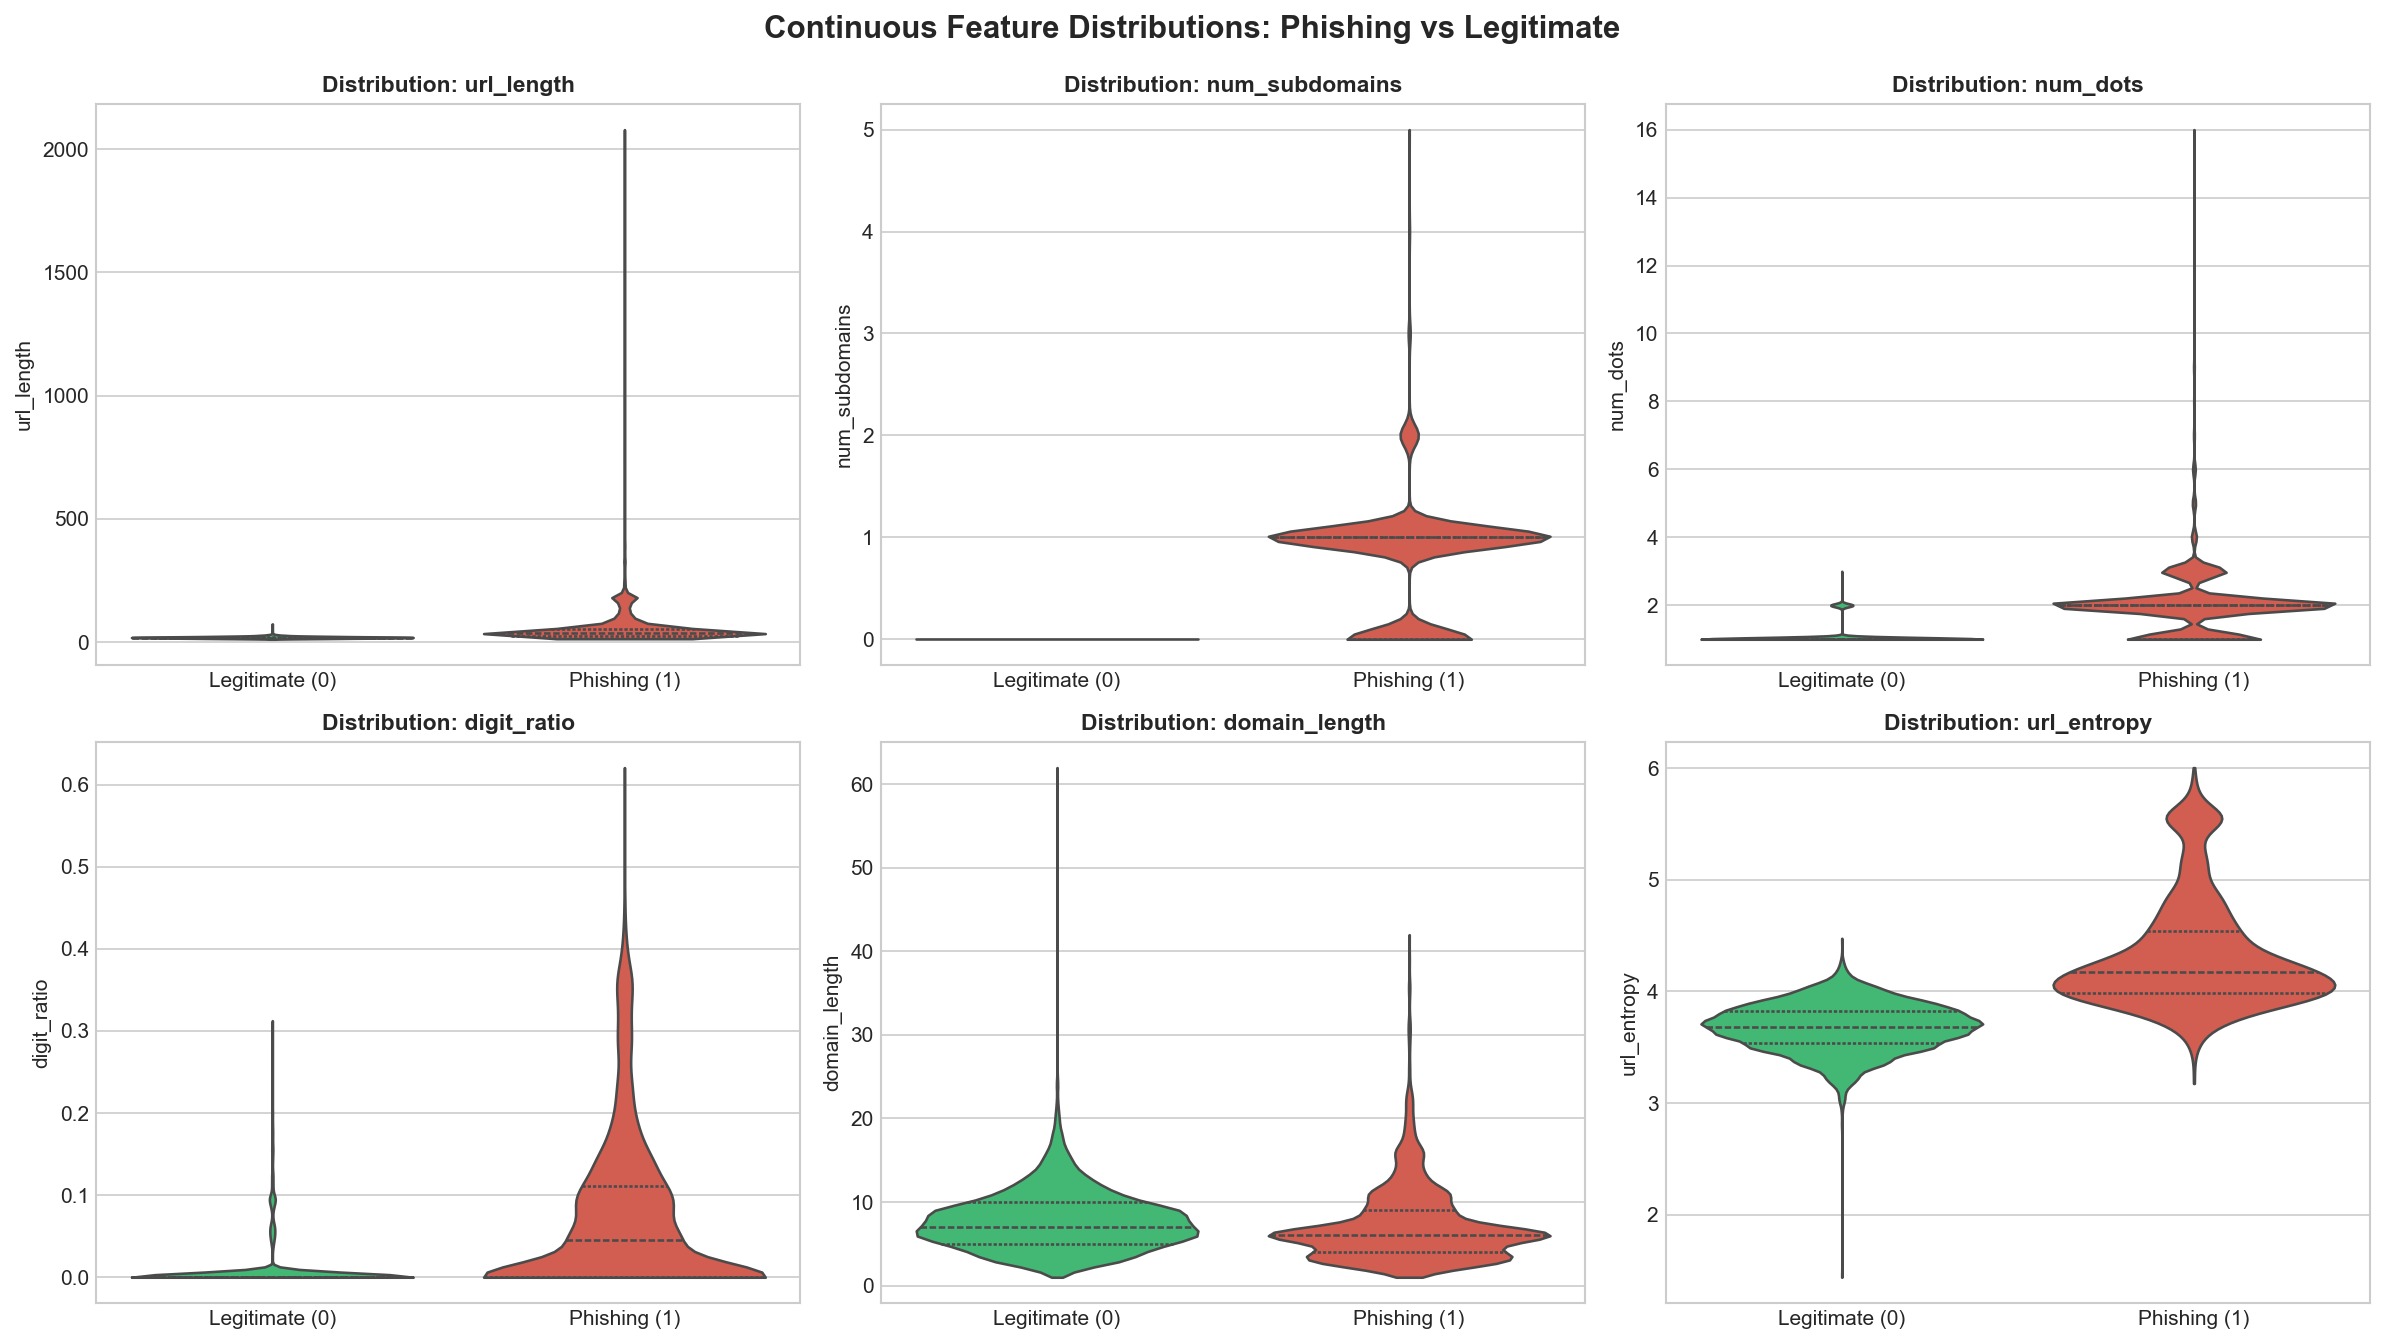

In [3]:
key_features = [
    "url_length", "num_subdomains", "num_dots",
    "digit_ratio", "domain_length", "url_entropy"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=150)
axes = axes.flatten()

palette = ["#2ecc71", "#e74c3c"]

for i, feat in enumerate(key_features):
    sns.violinplot(
        data=df, x="label", y=feat, hue="label", ax=axes[i],
        palette=palette, inner="quartile", cut=0, legend=False
    )
    axes[i].set_title(f"Distribution: {feat}", fontweight="bold", fontsize=11)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Legitimate (0)", "Phishing (1)"], fontweight="medium")
    axes[i].set_xlabel("")
    axes[i].set_ylabel(feat, fontsize=10)

plt.suptitle("Continuous Feature Distributions: Phishing vs Legitimate", fontsize=15, fontweight="bold", y=0.99)
plt.tight_layout()
plt.savefig(EVAL_DIR / "feature_distributions.png", dpi=150)
plt.show()


## 3. Boolean Feature Prevalence by Class
Comparing the percentage of URLs in each class that trigger specific binary indicators:
- `has_ip_address`: Raw IP addresses in hostnames.
- `has_at_symbol`: Credential obfuscation symbol (@).
- `has_https`: HTTPS presence (note: missing HTTPS is a phishing indicator, though attackers also use free TLS).
- `has_suspicious_tld`: Free/abused TLDs (.tk, .ml, .xyz, etc.).
- `has_url_shortener`: Known URL shortener services.
- `has_double_slash_in_path`: Path redirection obfuscation.
- `has_brand_keyword_mismatch`: High-confidence brand impersonation signal.
- `has_redirect_in_query`: Open redirect detection.
- `has_port_in_url`: Non-standard port specification.


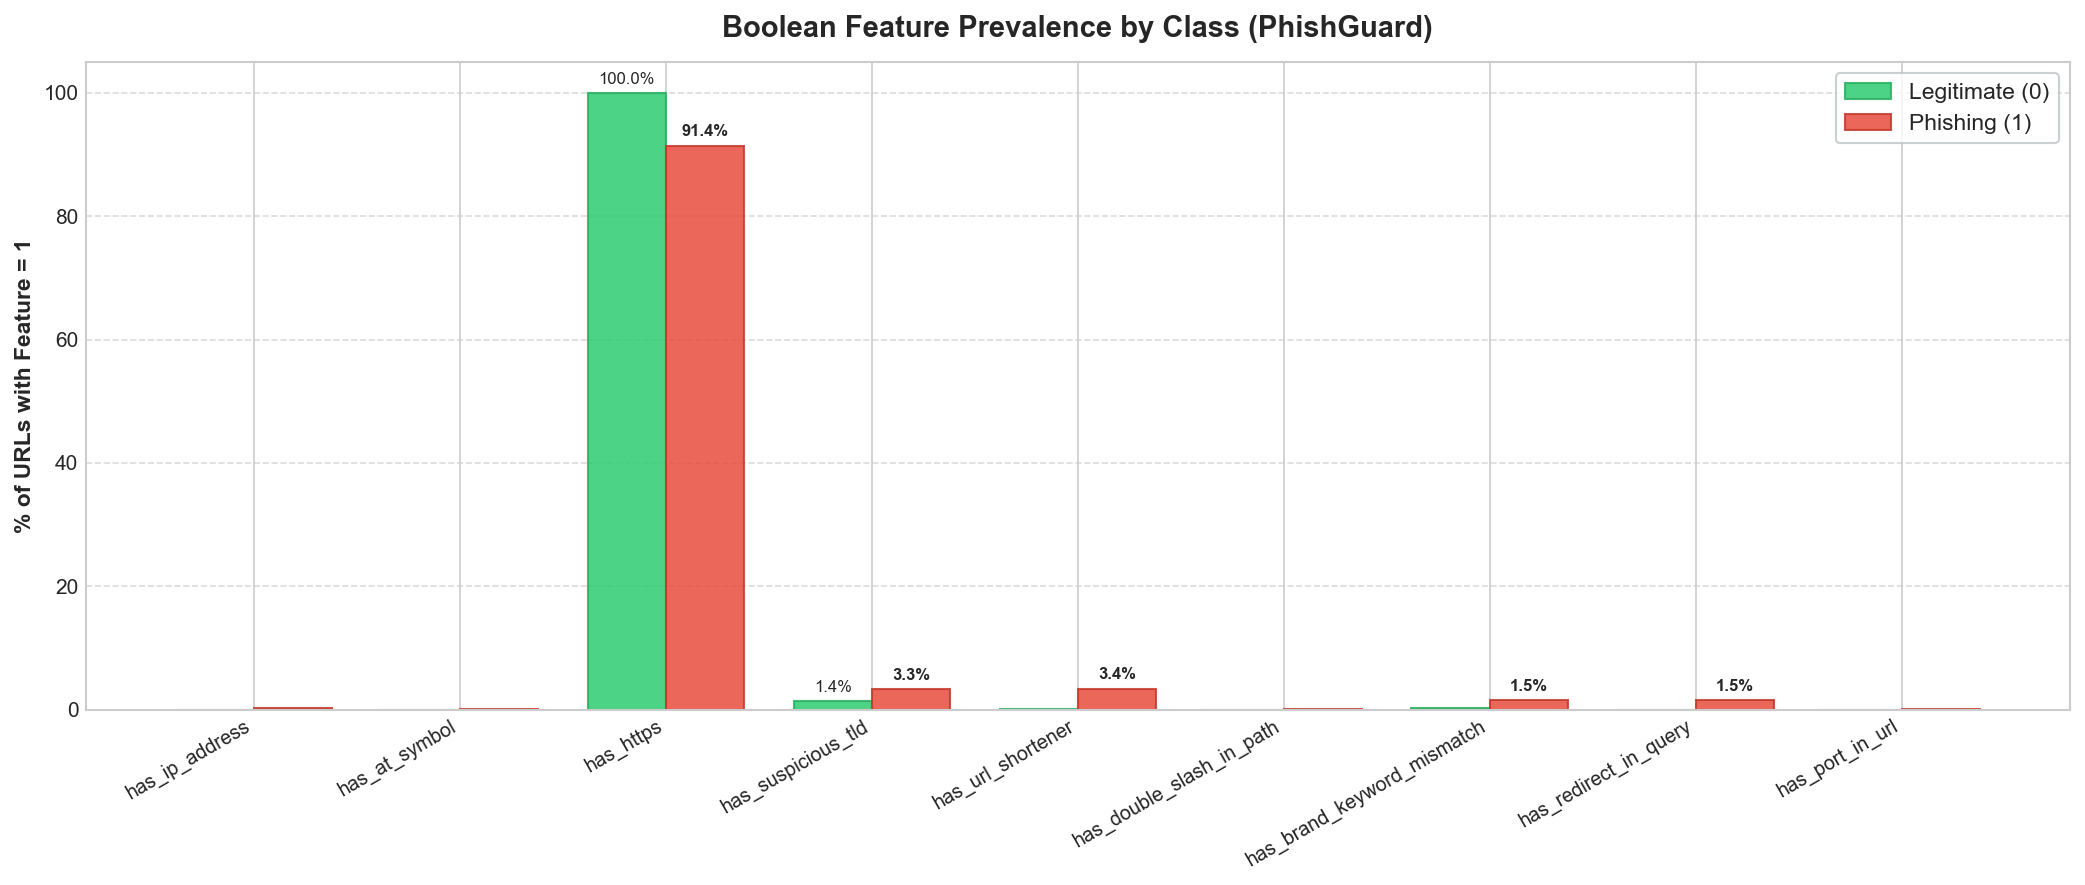

In [4]:
bool_features = [
    "has_ip_address", "has_at_symbol", "has_https", "has_suspicious_tld",
    "has_url_shortener", "has_double_slash_in_path",
    "has_brand_keyword_mismatch", "has_redirect_in_query", "has_port_in_url"
]

phishing = df[df["label"] == 1]
legit = df[df["label"] == 0]
phish_rates = [phishing[f].mean() * 100 for f in bool_features]
legit_rates = [legit[f].mean() * 100 for f in bool_features]

x = np.arange(len(bool_features))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
rects1 = ax.bar(x - width/2, legit_rates, width, label="Legitimate (0)", color="#2ecc71", alpha=0.85, edgecolor="#27ae60")
rects2 = ax.bar(x + width/2, phish_rates, width, label="Phishing (1)", color="#e74c3c", alpha=0.85, edgecolor="#c0392b")

ax.set_ylabel("% of URLs with Feature = 1", fontsize=11, fontweight="bold")
ax.set_title("Boolean Feature Prevalence by Class (PhishGuard)", fontsize=14, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(bool_features, rotation=30, ha="right", fontsize=9.5, fontweight="medium")
ax.legend(frameon=True, facecolor="white", edgecolor="#bdc3c7", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Add text percentage labels above bars
for rect in rects1:
    h = rect.get_height()
    if h > 1.0:
        ax.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

for rect in rects2:
    h = rect.get_height()
    if h > 1.0:
        ax.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(EVAL_DIR / "boolean_feature_prevalence.png", dpi=150)
plt.show()


## 4. Feature Correlation Matrix
Evaluating pairwise linear correlations among all 19 handcrafted features and the target label.
This confirms the discriminative power of the feature set and highlights any multi-collinear pairs.


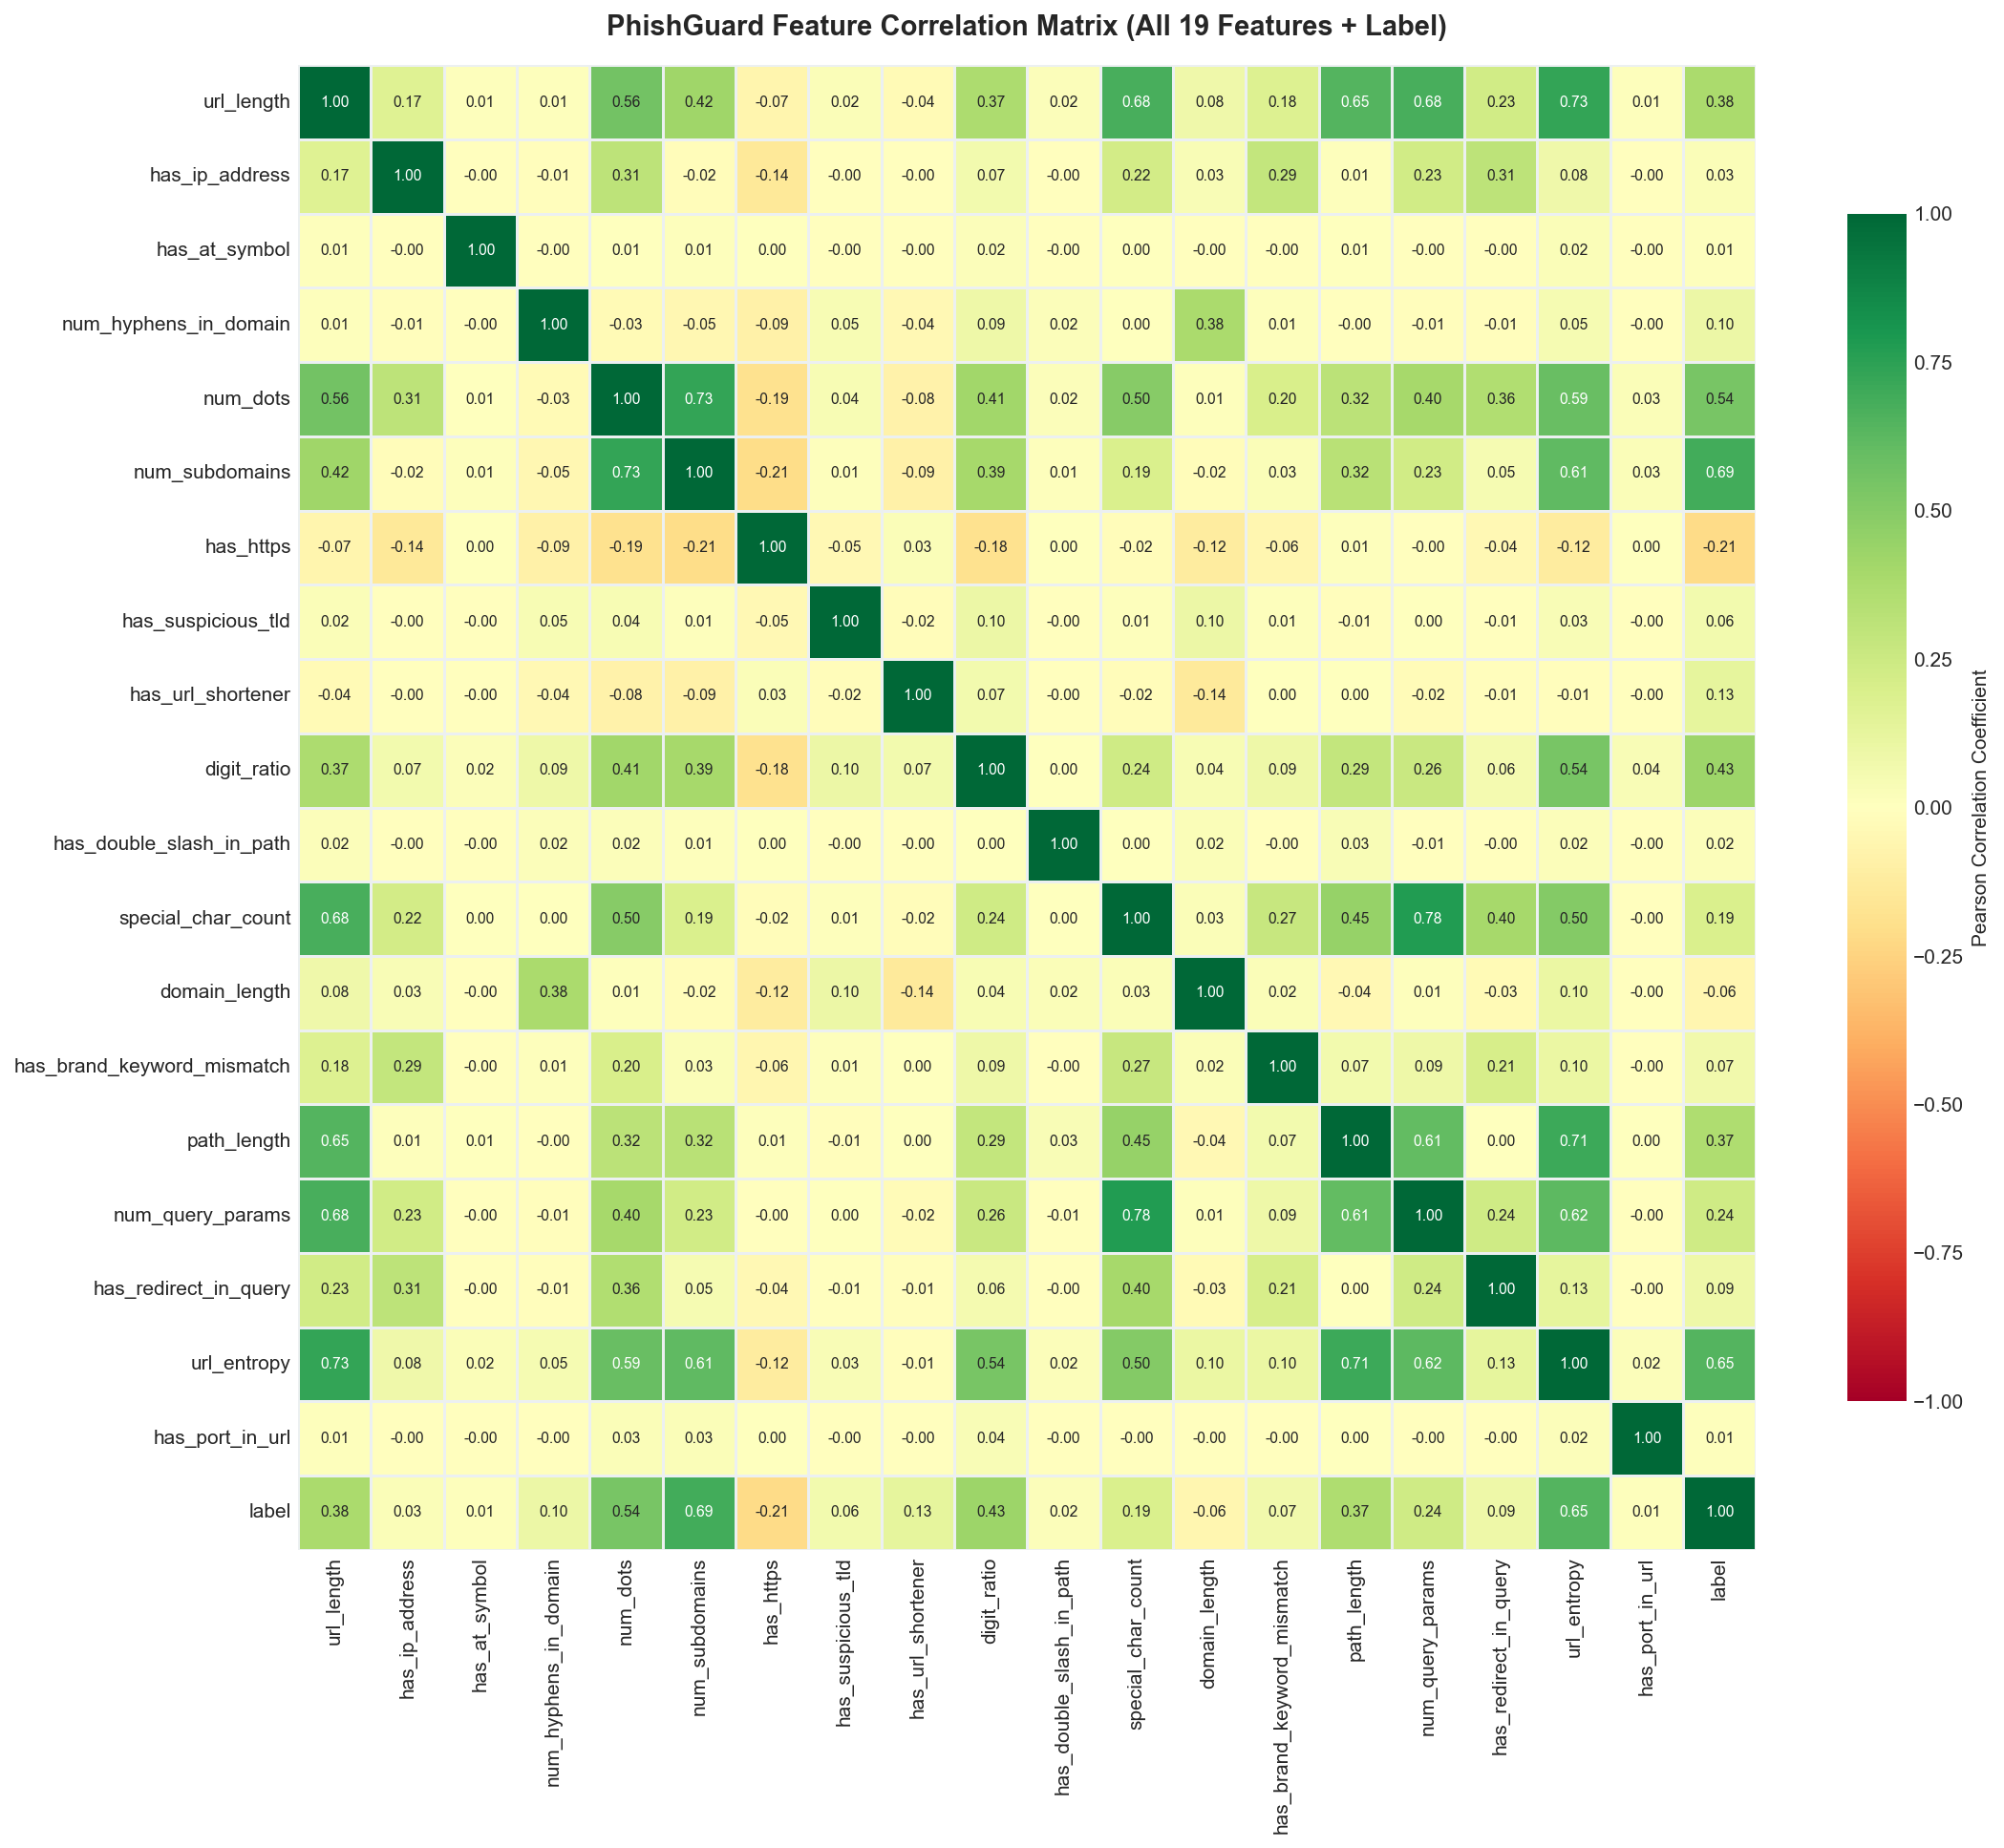

In [5]:
numeric_features = [c for c in df.columns if c not in ["url", "label"]]
corr = df[numeric_features + ["label"]].corr()

fig, ax = plt.subplots(figsize=(15, 13), dpi=150)
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1, ax=ax,
    annot_kws={"size": 7.5, "weight": "medium"},
    linewidths=0.5, linecolor="#ecf0f1",
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"}
)
ax.set_title("PhishGuard Feature Correlation Matrix (All 19 Features + Label)", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(EVAL_DIR / "correlation_heatmap.png", dpi=150)
plt.show()


## 5. Key Statistics for Research Report
Quantified summary metrics ready for citation in the project report.


In [6]:
print("=" * 60)
print("PHISHGUARD EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 60)

print(f"Total Dataset Size: {len(df):,} URLs")
print("\n=== Class Distribution ===")
for lbl, count in df["label"].value_counts().sort_index().items():
    name = "Legitimate" if lbl == 0 else "Phishing"
    print(f"  Class {lbl} ({name}): {count:,} ({count/len(df)*100:.1f}%)")

print("\n=== Mean URL Length by Class ===")
mean_lens = df.groupby("label")["url_length"].mean()
print(f"  Legitimate: {mean_lens[0]:.2f} characters")
print(f"  Phishing:   {mean_lens[1]:.2f} characters (Δ = {mean_lens[1] - mean_lens[0]:+.2f})")

print("\n=== Suspicious TLD Prevalence ===")
tld_legit = legit['has_suspicious_tld'].mean() * 100
tld_phish = phishing['has_suspicious_tld'].mean() * 100
print(f"  Legitimate: {tld_legit:.2f}%")
print(f"  Phishing:   {tld_phish:.2f}%")

print("\n=== Missing HTTPS Rate ===")
https_legit = (1 - legit['has_https'].mean()) * 100
https_phish = (1 - phishing['has_https'].mean()) * 100
print(f"  Legitimate (HTTP only): {https_legit:.2f}%")
print(f"  Phishing (HTTP only):   {https_phish:.2f}%")

print("\n=== Brand Keyword Mismatch Prevalence ===")
mismatch_legit = legit['has_brand_keyword_mismatch'].mean() * 100
mismatch_phish = phishing['has_brand_keyword_mismatch'].mean() * 100
print(f"  Legitimate: {mismatch_legit:.2f}%")
print(f"  Phishing:   {mismatch_phish:.2f}%")

print("\n=== Top 5 Features Correlated with Target (Phishing) ===")
label_corrs = corr["label"].drop("label").sort_values(ascending=False)
for feat, c_val in label_corrs.head(5).items():
    print(f"  {feat:<28}: r = {c_val:+.4f}")

print("\n=== Top 3 Negative Correlations (Protective / Legit Features) ===")
for feat, c_val in label_corrs.tail(3).items():
    print(f"  {feat:<28}: r = {c_val:+.4f}")
print("=" * 60)


PHISHGUARD EXPLORATORY DATA ANALYSIS SUMMARY
Total Dataset Size: 10,000 URLs

=== Class Distribution ===
  Class 0 (Legitimate): 5,000 (50.0%)
  Class 1 (Phishing): 5,000 (50.0%)

=== Mean URL Length by Class ===
  Legitimate: 19.80 characters
  Phishing:   55.93 characters (Δ = +36.14)

=== Suspicious TLD Prevalence ===
  Legitimate: 1.36%
  Phishing:   3.26%

=== Missing HTTPS Rate ===
  Legitimate (HTTP only): 0.00%
  Phishing (HTTP only):   8.56%

=== Brand Keyword Mismatch Prevalence ===
  Legitimate: 0.20%
  Phishing:   1.52%

=== Top 5 Features Correlated with Target (Phishing) ===
  num_subdomains              : r = +0.6932
  url_entropy                 : r = +0.6469
  num_dots                    : r = +0.5448
  digit_ratio                 : r = +0.4251
  url_length                  : r = +0.3778

=== Top 3 Negative Correlations (Protective / Legit Features) ===
  has_port_in_url             : r = +0.0100
  domain_length               : r = -0.0584
  has_https                  